In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from akita_model.model import SeqNN

In [3]:
FOLD = 0

# fold 0 - test
# fold 1 - valid
# folds 2-7 - train

In [4]:
TARGET_C = -0.5

# TARGET_C = -10.0

In [5]:
df = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/fold{FOLD}_with_positions_steps_results_mod.tsv", sep="\t")

In [6]:
len(df)

46

In [ ]:
df.columns

In [7]:
class OriginalDataset(Dataset):
    def __init__(self, coord_df, init_seq_path):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
    
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True, map_location=device)
        X = X.squeeze(0)
        return X

In [ ]:
# ### SHUFLING THE ENTIRE SLICE   

# class BoundaryGenerationDataset(Dataset):
#     def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048, seed=42):
#         self.coords = coord_df
#         self.init_seq_path = init_seq_path
#         self.slice_path = slice_path
#         self.slice = slice
#         self.cropping = cropping
#         self.bin_size = bin_size
#         self.seed = seed
        
#     def __len__(self):
#         return len(self.coords)
    
#     def shuffle_nucleotides_in_slice(self, slice_tensor, seed):
#         """
#         Shuffle nucleotides within the slice to destroy motifs.
#         slice_tensor shape: [1, 4, 2048]
#         """
#         # Set seed for this specific slice
#         torch.manual_seed(seed)
        
#         # Convert one-hot to indices (which nucleotide at each position)
#         indices = torch.argmax(slice_tensor[0], dim=0)  # [2048]
        
#         # Shuffle the indices
#         perm = torch.randperm(indices.shape[0])
#         shuffled_indices = indices[perm]
        
#         # Convert back to one-hot
#         shuffled_slice = torch.zeros_like(slice_tensor)
#         for i, idx in enumerate(shuffled_indices):
#             shuffled_slice[0, idx, i] = 1
        
#         return shuffled_slice

#     def __getitem__(self, idx):
#         row = self.coords.iloc[idx]
#         chrom = row["chrom"]
#         start = row["centered_start"]
#         end = row["centered_end"]
        
#         device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
#         X = torch.load(
#             f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt",
#             weights_only=True,
#             map_location=device
#         )
#         slice_edited = torch.load(
#             f"{self.slice_path}{chrom}_{start}_{end}_slice.pt",
#             weights_only=True,
#             map_location=device
#         )

#         # Shuffle nucleotides in the entire slice
#         slice_shuffled = self.shuffle_nucleotides_in_slice(slice_edited, self.seed + idx)

#         edit_start = (self.slice + self.cropping) * self.bin_size
#         edit_end = edit_start + self.bin_size
        
#         editedX = X.clone()
#         editedX[:, :, edit_start:edit_end] = slice_shuffled
        
#         editedX = editedX.squeeze(0)
        
#         return editedX

In [ ]:
# ### SHUFFLING EEVERYTHING BUT NOT THE ORIGINAL CTCFS (WITH FLANKS)

# class BoundaryGenerationDataset(Dataset):
#     def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048, seed=42, flank_size=15):
#         self.coords = coord_df
#         self.init_seq_path = init_seq_path
#         self.slice_path = slice_path
#         self.slice = slice
#         self.cropping = cropping
#         self.bin_size = bin_size
#         self.seed = seed
#         self.flank_size = flank_size
        
#     def __len__(self):
#         return len(self.coords)
    
#     def shuffle_nucleotides_except_regions(self, slice_tensor, protected_regions, seed):
#         """
#         Shuffle nucleotides in the slice EXCEPT for protected regions (original CTCFs + flanks).
#         slice_tensor shape: [1, 4, 2048]
#         protected_regions: list of (start, end) tuples to preserve
#         """
#         # Set seed
#         torch.manual_seed(seed)
        
#         # Create a mask of positions to shuffle (True = shuffle, False = keep)
#         length = slice_tensor.shape[2]
#         shuffle_mask = torch.ones(length, dtype=torch.bool)
        
#         # Mark protected regions as False (don't shuffle)
#         for start, end in protected_regions:
#             if 0 <= start < length and 0 <= end <= length:
#                 shuffle_mask[start:end] = False
        
#         # Get indices of positions to shuffle
#         shuffle_positions = torch.where(shuffle_mask)[0]
        
#         if len(shuffle_positions) == 0:
#             # Nothing to shuffle
#             return slice_tensor.clone()
        
#         # Extract nucleotides at shuffleable positions
#         indices = torch.argmax(slice_tensor[0], dim=0)  # [2048]
#         shuffleable_nucleotides = indices[shuffle_positions]
        
#         # Shuffle them
#         perm = torch.randperm(len(shuffleable_nucleotides))
#         shuffled_nucleotides = shuffleable_nucleotides[perm]
        
#         # Create output tensor (start with original)
#         shuffled_slice = slice_tensor.clone()
        
#         # Clear the shuffleable positions
#         shuffled_slice[:, :, shuffle_positions] = 0
        
#         # Put shuffled nucleotides back
#         for i, pos in enumerate(shuffle_positions):
#             nuc_idx = shuffled_nucleotides[i]
#             shuffled_slice[0, nuc_idx, pos] = 1
        
#         return shuffled_slice

#     def __getitem__(self, idx):
#         row = self.coords.iloc[idx]
#         chrom = row["chrom"]
#         start = row["centered_start"]
#         end = row["centered_end"]
        
#         device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
#         X = torch.load(
#             f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt",
#             weights_only=True,
#             map_location=device
#         )
#         slice_edited = torch.load(
#             f"{self.slice_path}{chrom}_{start}_{end}_slice.pt",
#             weights_only=True,
#             map_location=device
#         )

#         # Get original CTCF positions to protect (with flanks)
#         protected_regions = []
#         if 'orig_CTCFs_coord' in row and row['orig_CTCFs_coord']:
#             orig_ctcfs = row['orig_CTCFs_coord']
            
#             # Convert from string to set if needed
#             if isinstance(orig_ctcfs, str):
#                 import ast
#                 orig_ctcfs = ast.literal_eval(orig_ctcfs)
            
#             # Collect regions to protect with ±15bp flanks
#             for ctcf_start, ctcf_end, strand in orig_ctcfs:
#                 # Add flanks
#                 protected_start = max(0, ctcf_start - self.flank_size)
#                 protected_end = min(self.bin_size, ctcf_end + self.flank_size)
                
#                 # Only protect if within bounds
#                 if 0 <= protected_start < self.bin_size and 0 <= protected_end <= self.bin_size:
#                     protected_regions.append((protected_start, protected_end))
        
#         if idx < 3:
#             print(f"\nSequence {idx}: Protecting {len(protected_regions)} original CTCF regions with ±{self.flank_size}bp flanks:")
#             for start, end in protected_regions:
#                 print(f"  {start}-{end} (length={end-start}bp)")
        
#         # Shuffle everything except original CTCFs + flanks
#         slice_shuffled = self.shuffle_nucleotides_except_regions(
#             slice_edited, 
#             protected_regions, 
#             self.seed + idx
#         )

#         edit_start = (self.slice + self.cropping) * self.bin_size
#         edit_end = edit_start + self.bin_size
        
#         editedX = X.clone()
#         editedX[:, :, edit_start:edit_end] = slice_shuffled
        
#         editedX = editedX.squeeze(0)
        
#         return editedX

In [ ]:
# ### SHUFFLING EVERYTHING BUT NOT THE ORIGINAL AND NEWLY ADDED CTCFS (WITH FLANKS)

# class BoundaryGenerationDataset(Dataset):
#     def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048, seed=42, flank_size=15):
#         self.coords = coord_df
#         self.init_seq_path = init_seq_path
#         self.slice_path = slice_path
#         self.slice = slice
#         self.cropping = cropping
#         self.bin_size = bin_size
#         self.seed = seed
#         self.flank_size = flank_size
        
#     def __len__(self):
#         return len(self.coords)
    
#     def shuffle_nucleotides_except_regions(self, slice_tensor, protected_regions, seed):
#         """
#         Shuffle nucleotides in the slice EXCEPT for protected regions (CTCFs + flanks).
#         slice_tensor shape: [1, 4, 2048]
#         protected_regions: list of (start, end) tuples to preserve
#         """
#         # Set seed
#         torch.manual_seed(seed)
        
#         # Create a mask of positions to shuffle (True = shuffle, False = keep)
#         length = slice_tensor.shape[2]
#         shuffle_mask = torch.ones(length, dtype=torch.bool)
        
#         # Mark protected regions as False (don't shuffle)
#         for start, end in protected_regions:
#             if 0 <= start < length and 0 <= end <= length:
#                 shuffle_mask[start:end] = False
        
#         # Get indices of positions to shuffle
#         shuffle_positions = torch.where(shuffle_mask)[0]
        
#         if len(shuffle_positions) == 0:
#             # Nothing to shuffle
#             return slice_tensor.clone()
        
#         # Extract nucleotides at shuffleable positions
#         indices = torch.argmax(slice_tensor[0], dim=0)  # [2048]
#         shuffleable_nucleotides = indices[shuffle_positions]
        
#         # Shuffle them
#         perm = torch.randperm(len(shuffleable_nucleotides))
#         shuffled_nucleotides = shuffleable_nucleotides[perm]
        
#         # Create output tensor (start with original)
#         shuffled_slice = slice_tensor.clone()
        
#         # Clear the shuffleable positions
#         shuffled_slice[:, :, shuffle_positions] = 0
        
#         # Put shuffled nucleotides back
#         for i, pos in enumerate(shuffle_positions):
#             nuc_idx = shuffled_nucleotides[i]
#             shuffled_slice[0, nuc_idx, pos] = 1
        
#         return shuffled_slice

#     def __getitem__(self, idx):
#         row = self.coords.iloc[idx]
#         chrom = row["chrom"]
#         start = row["centered_start"]
#         end = row["centered_end"]
        
#         device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
#         X = torch.load(
#             f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt",
#             weights_only=True,
#             map_location=device
#         )
#         slice_edited = torch.load(
#             f"{self.slice_path}{chrom}_{start}_{end}_slice.pt",
#             weights_only=True,
#             map_location=device
#         )

#         # Get BOTH original AND new CTCF positions to protect (with flanks)
#         protected_regions = []
        
#         # Protect original CTCFs
#         if 'orig_CTCFs_coord' in row and row['orig_CTCFs_coord']:
#             orig_ctcfs = row['orig_CTCFs_coord']
            
#             # Convert from string to set if needed
#             if isinstance(orig_ctcfs, str):
#                 import ast
#                 orig_ctcfs = ast.literal_eval(orig_ctcfs)
            
#             # Collect regions to protect with ±15bp flanks
#             for ctcf_start, ctcf_end, strand in orig_ctcfs:
#                 # Add flanks
#                 protected_start = max(0, ctcf_start - self.flank_size)
#                 protected_end = min(self.bin_size, ctcf_end + self.flank_size)
                
#                 # Only protect if within bounds
#                 if 0 <= protected_start < self.bin_size and 0 <= protected_end <= self.bin_size:
#                     protected_regions.append((protected_start, protected_end))
        
#         # Protect new CTCFs
#         if 'new_CTCFs_coord' in row and row['new_CTCFs_coord']:
#             new_ctcfs = row['new_CTCFs_coord']
            
#             # Convert from string to set if needed
#             if isinstance(new_ctcfs, str):
#                 import ast
#                 new_ctcfs = ast.literal_eval(new_ctcfs)
            
#             # Collect regions to protect with ±15bp flanks
#             for ctcf_start, ctcf_end, strand in new_ctcfs:
#                 # Add flanks
#                 protected_start = max(0, ctcf_start - self.flank_size)
#                 protected_end = min(self.bin_size, ctcf_end + self.flank_size)
                
#                 # Only protect if within bounds
#                 if 0 <= protected_start < self.bin_size and 0 <= protected_end <= self.bin_size:
#                     protected_regions.append((protected_start, protected_end))
        
#         if idx < 3:
#             print(f"\nSequence {idx}: Protecting {len(protected_regions)} CTCF regions (orig + new) with ±{self.flank_size}bp flanks")
        
#         # Shuffle everything except ALL CTCFs + flanks
#         slice_shuffled = self.shuffle_nucleotides_except_regions(
#             slice_edited, 
#             protected_regions, 
#             self.seed + idx
#         )

#         edit_start = (self.slice + self.cropping) * self.bin_size
#         edit_end = edit_start + self.bin_size
        
#         editedX = X.clone()
#         editedX[:, :, edit_start:edit_end] = slice_shuffled
        
#         editedX = editedX.squeeze(0)
        
#         return editedX

In [ ]:
# ### SHUFFLING ONLY SUPPRESSING CTCFS

# class BoundaryGenerationDataset(Dataset):
#     def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048, seed=42):
#         self.coords = coord_df
#         self.init_seq_path = init_seq_path
#         self.slice_path = slice_path
#         self.slice = slice
#         self.cropping = cropping
#         self.bin_size = bin_size
#         self.seed = seed
        
#     def __len__(self):
#         return len(self.coords)
    
#     def shuffle_sequence_region(self, seq_tensor, start, end, seed):
#         """
#         Shuffle nucleotides within a specific region.
#         seq_tensor shape: [1, 4, seq_len]
#         """
#         # Set seed
#         torch.manual_seed(seed)
        
#         # Extract the region
#         region = seq_tensor[:, :, start:end].clone()  # [1, 4, length]
#         length = end - start
        
#         # Convert one-hot to indices
#         indices = torch.argmax(region[0], dim=0)  # [length]
        
#         # Shuffle
#         perm = torch.randperm(length)
#         shuffled_indices = indices[perm]
        
#         # Convert back to one-hot
#         shuffled_region = torch.zeros_like(region)
#         for i, idx in enumerate(shuffled_indices):
#             shuffled_region[0, idx, i] = 1
        
#         # Put it back
#         seq_tensor[:, :, start:end] = shuffled_region
        
#         return seq_tensor

#     def __getitem__(self, idx):
#         row = self.coords.iloc[idx]
#         chrom = row["chrom"]
#         start = row["centered_start"]
#         end = row["centered_end"]
        
#         device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
#         X = torch.load(
#             f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt",
#             weights_only=True,
#             map_location=device
#         )
#         slice_edited = torch.load(
#             f"{self.slice_path}{chrom}_{start}_{end}_slice.pt",
#             weights_only=True,
#             map_location=device
#         )

#         # Clone the slice
#         modified_slice = slice_edited.clone()
        
#         # Shuffle ONLY the new CTCFs
#         if 'new_CTCFs_coord' in row and row['new_CTCFs_coord']:
#             new_ctcfs = row['new_CTCFs_coord']
            
#             # Convert from string to set if needed
#             if isinstance(new_ctcfs, str):
#                 import ast
#                 new_ctcfs = ast.literal_eval(new_ctcfs)
            
#             # Filter CTCFs within the editable region (0-2048)
#             valid_ctcfs = [(s, e, strand) for s, e, strand in new_ctcfs 
#                           if 0 <= s < self.bin_size and 0 <= e <= self.bin_size]
            
#             if valid_ctcfs:
#                 # Set seed for reproducibility
#                 torch.manual_seed(self.seed + idx)
                
#                 if idx < 3:
#                     print(f"\nSequence {idx}: Shuffling {len(valid_ctcfs)} new CTCF motifs only")
                
#                 # Shuffle each new CTCF motif
#                 for ctcf_idx, (ctcf_start, ctcf_end, strand) in enumerate(valid_ctcfs):
#                     if idx < 3:
#                         print(f"  Shuffling new CTCF at {ctcf_start}-{ctcf_end} (strand={strand})")
                    
#                     # Shuffle this CTCF with a unique seed
#                     modified_slice = self.shuffle_sequence_region(
#                         modified_slice, 
#                         ctcf_start, 
#                         ctcf_end, 
#                         self.seed + idx + ctcf_idx
#                     )

#         # Insert the modified slice into X
#         edit_start = (self.slice + self.cropping) * self.bin_size
#         edit_end = edit_start + self.bin_size
        
#         editedX = X.clone()
#         editedX[:, :, edit_start:edit_end] = modified_slice
        
#         editedX = editedX.squeeze(0)
        
#         return editedX

In [ ]:
# ### SHUFFLING ONLY ORIGINAL CTCFS

# class BoundaryGenerationDataset(Dataset):
#     def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048, seed=42):
#         self.coords = coord_df
#         self.init_seq_path = init_seq_path
#         self.slice_path = slice_path
#         self.slice = slice
#         self.cropping = cropping
#         self.bin_size = bin_size
#         self.seed = seed
        
#     def __len__(self):
#         return len(self.coords)
    
#     def shuffle_sequence_region(self, seq_tensor, start, end, seed):
#         """
#         Shuffle nucleotides within a specific region.
#         seq_tensor shape: [1, 4, seq_len]
#         """
#         # Set seed
#         torch.manual_seed(seed)
        
#         # Extract the region
#         region = seq_tensor[:, :, start:end].clone()  # [1, 4, length]
#         length = end - start
        
#         # Convert one-hot to indices
#         indices = torch.argmax(region[0], dim=0)  # [length]
        
#         # Shuffle
#         perm = torch.randperm(length)
#         shuffled_indices = indices[perm]
        
#         # Convert back to one-hot
#         shuffled_region = torch.zeros_like(region)
#         for i, idx in enumerate(shuffled_indices):
#             shuffled_region[0, idx, i] = 1
        
#         # Put it back
#         seq_tensor[:, :, start:end] = shuffled_region
        
#         return seq_tensor

#     def __getitem__(self, idx):
#         row = self.coords.iloc[idx]
#         chrom = row["chrom"]
#         start = row["centered_start"]
#         end = row["centered_end"]
        
#         device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
#         X = torch.load(
#             f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt",
#             weights_only=True,
#             map_location=device
#         )
#         slice_edited = torch.load(
#             f"{self.slice_path}{chrom}_{start}_{end}_slice.pt",
#             weights_only=True,
#             map_location=device
#         )

#         # Clone the slice
#         modified_slice = slice_edited.clone()
        
#         # Shuffle ONLY the new CTCFs
#         if 'orig_CTCFs_coord' in row and row['orig_CTCFs_coord']:
#             new_ctcfs = row['orig_CTCFs_coord']
            
#             # Convert from string to set if needed
#             if isinstance(new_ctcfs, str):
#                 import ast
#                 new_ctcfs = ast.literal_eval(new_ctcfs)
            
#             # Filter CTCFs within the editable region (0-2048)
#             valid_ctcfs = [(s, e, strand) for s, e, strand in new_ctcfs 
#                           if 0 <= s < self.bin_size and 0 <= e <= self.bin_size]
            
#             if valid_ctcfs:
#                 # Set seed for reproducibility
#                 torch.manual_seed(self.seed + idx)
                
#                 if idx < 3:
#                     print(f"\nSequence {idx}: Shuffling {len(valid_ctcfs)} new CTCF motifs only")
                
#                 # Shuffle each new CTCF motif
#                 for ctcf_idx, (ctcf_start, ctcf_end, strand) in enumerate(valid_ctcfs):
#                     if idx < 3:
#                         print(f"  Shuffling new CTCF at {ctcf_start}-{ctcf_end} (strand={strand})")
                    
#                     # Shuffle this CTCF with a unique seed
#                     modified_slice = self.shuffle_sequence_region(
#                         modified_slice, 
#                         ctcf_start, 
#                         ctcf_end, 
#                         self.seed + idx + ctcf_idx
#                     )

#         # Insert the modified slice into X
#         edit_start = (self.slice + self.cropping) * self.bin_size
#         edit_end = edit_start + self.bin_size
        
#         editedX = X.clone()
#         editedX[:, :, edit_start:edit_end] = modified_slice
        
#         editedX = editedX.squeeze(0)
        
#         return editedX

In [ ]:
# ### INSERT CTCFS WITHOUT THE EDITED SLICE

# class BoundaryGenerationDataset(Dataset):
#     def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048, flank_size=15):
#         self.coords = coord_df
#         self.init_seq_path = init_seq_path
#         self.slice_path = slice_path
#         self.slice = slice
#         self.cropping = cropping
#         self.bin_size = bin_size
#         self.flank_size = flank_size
        
#     def __len__(self):
#         return len(self.coords)

#     def __getitem__(self, idx):
#         row = self.coords.iloc[idx]
#         chrom = row["chrom"]
#         start = row["centered_start"]
#         end = row["centered_end"]
        
#         device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
#         # Load original sequence
#         X = torch.load(
#             f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt",
#             weights_only=True,
#             map_location=device
#         )
        
#         # Load edited slice
#         slice_edited = torch.load(
#             f"{self.slice_path}{chrom}_{start}_{end}_slice.pt",
#             weights_only=True,
#             map_location=device
#         )
        
#         edit_start = (self.slice + self.cropping) * self.bin_size
#         edit_end = edit_start + self.bin_size
        
#         # Start with the ORIGINAL sequence (not the edited one)
#         editedX = X.clone()
        
#         # # Extract and insert ORIGINAL CTCFs with flanks
#         # if 'orig_CTCFs_coord' in row and row['orig_CTCFs_coord']:
#         #     orig_ctcfs = row['orig_CTCFs_coord']
            
#         #     if isinstance(orig_ctcfs, str):
#         #         import ast
#         #         orig_ctcfs = ast.literal_eval(orig_ctcfs)
            
#         #     for ctcf_start, ctcf_end, strand in orig_ctcfs:
#         #         if 0 <= ctcf_start < self.bin_size and 0 <= ctcf_end <= self.bin_size:
#         #             # Extract CTCF with flanks from edited slice
#         #             extract_start = max(0, ctcf_start - self.flank_size)
#         #             extract_end = min(self.bin_size, ctcf_end + self.flank_size)
                    
#         #             ctcf_with_flanks = slice_edited[:, :, extract_start:extract_end]
                    
#         #             # Insert into original sequence at the same position
#         #             abs_start = edit_start + extract_start
#         #             abs_end = edit_start + extract_end
                    
#         #             editedX[:, :, abs_start:abs_end] = ctcf_with_flanks
        
#         # Extract and insert NEW CTCFs with flanks
#         if 'new_CTCFs_coord' in row and row['new_CTCFs_coord']:
#             new_ctcfs = row['new_CTCFs_coord']
            
#             if isinstance(new_ctcfs, str):
#                 import ast
#                 new_ctcfs = ast.literal_eval(new_ctcfs)
            
#             for ctcf_start, ctcf_end, strand in new_ctcfs:
#                 if 0 <= ctcf_start < self.bin_size and 0 <= ctcf_end <= self.bin_size:
#                     # Extract CTCF with flanks from edited slice
#                     extract_start = max(0, ctcf_start - self.flank_size)
#                     extract_end = min(self.bin_size, ctcf_end + self.flank_size)
                    
#                     ctcf_with_flanks = slice_edited[:, :, extract_start:extract_end]
                    
#                     # Insert into original sequence at the same position
#                     abs_start = edit_start + extract_start
#                     abs_end = edit_start + extract_end
                    
#                     editedX[:, :, abs_start:abs_end] = ctcf_with_flanks
        
#         # if idx < 3:
#             # orig_count = len(row['orig_CTCFs_coord']) if 'orig_CTCFs_coord' in row and row['orig_CTCFs_coord'] else 0
#             # new_count = len(row['new_CTCFs_coord']) if 'new_CTCFs_coord' in row and row['new_CTCFs_coord'] else 0
#             # print(f"Sequence {idx}: Inserted {orig_count} original + {new_count} new CTCFs (with ±{self.flank_size}bp flanks) into original sequence")
        
#         editedX = editedX.squeeze(0)
        
#         return editedX

In [8]:
### REPLACING G AND C HOMOPOLYMERS WITH AT REPEATS

import re
import torch

class BoundaryGenerationDataset(Dataset):
    def __init__(self, coord_df, init_seq_path, slice_path, slice=256, cropping=64, bin_size=2048):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.slice_path = slice_path
        self.slice = slice
        self.cropping = cropping
        self.bin_size = bin_size
        
    def __len__(self):
        return len(self.coords)
    
    def sequence_to_tensor(self, sequence, device):
        """Convert DNA sequence string to one-hot tensor."""
        mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
        tensor = torch.zeros(4, len(sequence), device=device)
        
        for i, base in enumerate(sequence):
            if base in mapping:
                tensor[mapping[base], i] = 1
        
        return tensor
    
    def tensor_to_sequence(self, seq_tensor):
        """Convert one-hot tensor to DNA sequence string."""
        if seq_tensor.dim() == 3:
            seq_tensor = seq_tensor.squeeze(0)
        
        nucleotides = ['A', 'C', 'G', 'T']
        indices = torch.argmax(seq_tensor, dim=0)
        sequence = ''.join([nucleotides[i] for i in indices])
        return sequence
    
    def replace_gc_homopolymers(self, slice_tensor, min_length=4):
        """
        Replace G and C homopolymers (length >= min_length) with AT repeats.
        
        Args:
            slice_tensor: [1, 4, 2048] tensor
            min_length: minimum homopolymer length to replace (default 4)
        
        Returns:
            Modified tensor with GC homopolymers replaced
        """
        device = slice_tensor.device
        
        # Convert to sequence
        sequence = self.tensor_to_sequence(slice_tensor)
        
        # Find and replace C homopolymers (CCCC+ -> ATAT...)
        pattern_c = f'C{{{min_length},}}'
        for match in re.finditer(pattern_c, sequence):
            length = len(match.group())
            # Create AT repeat of the same length
            # replacement = 'AT' * (length // 2) + ('A' if length % 2 == 1 else '')
            replacement = 'GC' * (length // 2) + ('C' if length % 2 == 1 else '')
            sequence = sequence[:match.start()] + replacement + sequence[match.end():]
        
        # Find and replace G homopolymers (GGGG+ -> ATAT...)
        pattern_g = f'G{{{min_length},}}'
        for match in re.finditer(pattern_g, sequence):
            length = len(match.group())
            # Create AT repeat of the same length
            # replacement = 'AT' * (length // 2) + ('A' if length % 2 == 1 else '')
            replacement = 'CG' * (length // 2) + ('C' if length % 2 == 1 else '')
            sequence = sequence[:match.start()] + replacement + sequence[match.end():]
        
        # Convert back to tensor
        modified_tensor = self.sequence_to_tensor(sequence, device)
        
        return modified_tensor.unsqueeze(0)  # Add batch dimension back

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]
        
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True, map_location=device)
        slice_edited = torch.load(f"{self.slice_path}{chrom}_{start}_{end}_slice.pt", weights_only=True, map_location=device)
        
        # Replace GC homopolymers (≥4bp) with AT repeats
        slice_modified = self.replace_gc_homopolymers(slice_edited, min_length=4)
        
        if idx < 3:
            # Debug output for first few sequences
            orig_seq = self.tensor_to_sequence(slice_edited)
            mod_seq = self.tensor_to_sequence(slice_modified)
            
            # Count replacements
            orig_c_runs = len(re.findall(r'C{4,}', orig_seq))
            orig_g_runs = len(re.findall(r'G{4,}', orig_seq))
            mod_c_runs = len(re.findall(r'C{4,}', mod_seq))
            mod_g_runs = len(re.findall(r'G{4,}', mod_seq))
            
            print(f"\nSequence {idx}:")
            print(f"  Original: C-runs(≥4bp)={orig_c_runs}, G-runs(≥4bp)={orig_g_runs}")
            print(f"  Modified: C-runs(≥4bp)={mod_c_runs}, G-runs(≥4bp)={mod_g_runs}")
            print(f"  Replaced: {orig_c_runs + orig_g_runs - mod_c_runs - mod_g_runs} homopolymers")
        
        edit_start = (self.slice + self.cropping) * self.bin_size
        edit_end = edit_start + self.bin_size
        
        editedX = X.clone()
        editedX[:, :, edit_start:edit_end] = slice_modified
        
        editedX = editedX.squeeze(0)
        
        return editedX

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
model = SeqNN()
model_path = (
    "/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/"
    "Hsieh2019_mESC/models/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [11]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [12]:
orig_dataset = OriginalDataset(df, f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/fold{FOLD}/")
orig_loader = DataLoader(orig_dataset, batch_size=4, shuffle=False)

In [13]:
edited_dataset = BoundaryGenerationDataset(df, 
                                f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/fold{FOLD}/", 
                                f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/fold{FOLD}/")

edited_loader = DataLoader(edited_dataset, batch_size=4, shuffle=False)

In [ ]:
# df

In [14]:
slice = 256
cropping = 64
bin_size = 2048

edit_start = (slice + cropping) * bin_size
edit_end = edit_start + bin_size

In [15]:
preds_all_orig = []
preds_all_reversed = []
urq_mean_values = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)

        preds_orig = model(orig_batch).cpu()
        preds_edited = model(edited_batch).cpu()

        preds_all_orig.extend(preds_orig)
        preds_all_reversed.extend(preds_edited)
        
        orig_maps = from_upper_triu_batch(preds_orig)
        edited_maps = from_upper_triu_batch(preds_edited)
        
        urq_mean = np.nanmean(edited_maps[:, 0:250, 260:512], axis=(1, 2))
        urq_mean_values.extend(urq_mean)


Sequence 0:
  Original: C-runs(≥4bp)=8, G-runs(≥4bp)=8
  Modified: C-runs(≥4bp)=0, G-runs(≥4bp)=0
  Replaced: 16 homopolymers

Sequence 1:
  Original: C-runs(≥4bp)=10, G-runs(≥4bp)=14
  Modified: C-runs(≥4bp)=0, G-runs(≥4bp)=0
  Replaced: 24 homopolymers

Sequence 2:
  Original: C-runs(≥4bp)=10, G-runs(≥4bp)=6
  Modified: C-runs(≥4bp)=0, G-runs(≥4bp)=0
  Replaced: 16 homopolymers


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


In [16]:
df["URQ_gc_homopolymers"] = urq_mean_values

In [ ]:
df[["URQ_init", "URQ_result", "URQ_shuffle_new"]]

In [17]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [18]:
plot_df = df[df["URQ_diff"] > 0]

In [ ]:
# plot_df[["URQ_result", "URQ_shuffle_new"]]

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# select only the columns you want
cols = ['URQ_init', 'URQ_homopolymers']

# reshape to long format
df_long = plot_df[cols].melt(var_name='Stage', value_name='URQ')

# enforce the order you want
order = ['URQ_init', 'URQ_homopolymers']

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_long,
    x='Stage',
    y='URQ',
    order=order
)

plt.xlabel('')
plt.ylabel('URQ')
plt.show()

In [22]:
df["URQ_gc_homopolymers"].mean()

-0.09607914

In [20]:
df.to_csv(f"/scratch1/smaruj/suppressing_CTCFs/results_repeated/fold{FOLD}_with_positions_steps_results_mod.tsv", sep="\t", index=False)

In [ ]:
df.columns

/tmp/SLURM_2576080/ipykernel_2338305/948024908.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


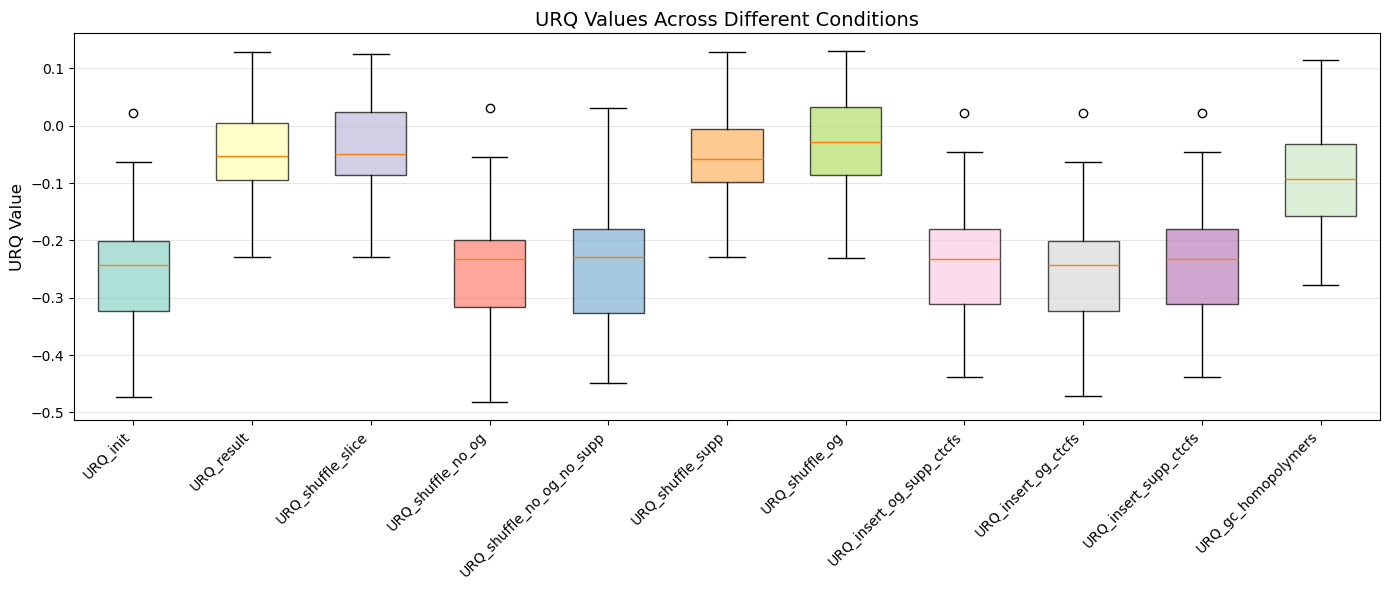

In [21]:
# Define the columns to plot
urq_columns = [
    'URQ_init',
    'URQ_result', 
    'URQ_shuffle_slice',
    'URQ_shuffle_no_og',
    'URQ_shuffle_no_og_no_supp',
    'URQ_shuffle_supp',
    'URQ_shuffle_og',
    'URQ_insert_og_supp_ctcfs',
    'URQ_insert_og_ctcfs',
    'URQ_insert_supp_ctcfs',
    'URQ_gc_homopolymers'
]

# Create the boxplot with filled boxes
fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    [plot_df[col].dropna() for col in urq_columns],
    labels=urq_columns,
    patch_artist=True,  # This enables filling
    widths=0.6
)

# Color the boxes
colors = plt.cm.Set3(range(len(urq_columns)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize the plot
ax.set_xticklabels(urq_columns, rotation=45, ha='right')
ax.set_ylabel('URQ Value', fontsize=12)
ax.set_title('URQ Values Across Different Conditions', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Print basic statistics for each URQ column
print("Basic Statistics for URQ Columns")
print("=" * 80)

for col in urq_columns:
    print(f"\n{col}:")
    print(f"  Mean:   {df[col].mean():.6f}")
    print(f"  Median: {df[col].median():.6f}")
    print(f"  Std:    {df[col].std():.6f}")
    print(f"  Min:    {df[col].min():.6f}")
    print(f"  Max:    {df[col].max():.6f}")

# Or use pandas describe for a more comprehensive view
print("\n" + "=" * 80)
print("\nComprehensive Statistics:")
print(df[urq_columns].describe().T)

In [ ]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [ ]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [ ]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [ ]:
pwm_ctcf = np.load("./PWM_with_flanks.npy")

In [ ]:
left_flank_slice = pwm_ctcf[:15, :]  
left_flank_transposed = left_flank_slice.T 
left_flank_tensor = torch.tensor(left_flank_transposed, dtype=torch.float32)

In [ ]:
right_flank_slice = pwm_ctcf[-15:, :]  
right_flank_transposed = right_flank_slice.T 
right_flank_tensor = torch.tensor(right_flank_transposed, dtype=torch.float32)

In [ ]:
motifs_dict = {"CTCF": pwm_CTCF_tensor,
               "left_flank": left_flank_tensor,
               "right_flank": right_flank_tensor}

In [ ]:
from memelite import fimo

In [ ]:
batch_size = 4

orig_num_CTCFs = []
num_CTCFs = []

orig_CTCFs_coord = []
new_CTCFs_coord = []

avg_orig_fimo_scores = []
avg_new_fimo_scores = []

avg_orig_left_fimo_scores = []
avg_new_left_fimo_scores = []

avg_orig_right_fimo_scores = []
avg_new_right_fimo_scores = []

extra_flank = 60

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        orig_slice = orig_batch[:, :, edit_start-extra_flank:edit_end+extra_flank]
        edited_slice = edited_batch[:, :, edit_start-extra_flank:edit_end+extra_flank]
        
        # original sequences
        ctcf_orig_hits, left_orig_hits, right_orig_hits = fimo(
            motifs=motifs_dict,
            sequences=orig_slice.cpu(),
            threshold=1e-4,
            reverse_complement=True
        )
        
        # Shift coordinates back to original reference
        ctcf_orig_hits["start"] -= extra_flank
        ctcf_orig_hits["end"]   -= extra_flank
        left_orig_hits["start"] -= extra_flank
        left_orig_hits["end"]   -= extra_flank
        right_orig_hits["start"] -= extra_flank
        right_orig_hits["end"]   -= extra_flank
        
        # edited sequences
        ctcf_edit_hits, left_edit_hits, right_edit_hits = fimo(
            motifs=motifs_dict,
            sequences=edited_slice.cpu(),
            threshold=1e-4,
            reverse_complement=True
        )

        # Shift coordinates back to original reference
        ctcf_edit_hits["start"] -= extra_flank
        ctcf_edit_hits["end"]   -= extra_flank
        left_edit_hits["start"] -= extra_flank
        left_edit_hits["end"]   -= extra_flank
        right_edit_hits["start"] -= extra_flank
        right_edit_hits["end"]   -= extra_flank
        
        for seq_idx in range(batch_size):
            # --- ORIGINAL, CTCF ---
            orig_seq_hits = ctcf_orig_hits[ctcf_orig_hits["sequence_name"] == seq_idx]
            if not orig_seq_hits.empty:
                orig_seq_hits = orig_seq_hits.sort_values(by="start")
                orig_num_CTCFs.append(len(orig_seq_hits))
                orig_ctcf_coords = set(zip(orig_seq_hits["start"], orig_seq_hits["end"], orig_seq_hits["strand"]))
                orig_fimo_score_avg = orig_seq_hits["score"].mean()
            else:
                orig_num_CTCFs.append(0)
                orig_ctcf_coords = set()
                orig_fimo_score_avg = 0.0
            orig_CTCFs_coord.append(orig_ctcf_coords)
            avg_orig_fimo_scores.append(orig_fimo_score_avg)
            
            # --- ORIGINAL, LEFT FLANK ---
            orig_left_hits = left_orig_hits[left_orig_hits["sequence_name"] == seq_idx]
            if not orig_left_hits.empty:
                orig_fimo_left_score_avg = orig_left_hits["score"].mean()
            else:
                orig_fimo_left_score_avg = 0.0
            avg_orig_left_fimo_scores.append(orig_fimo_left_score_avg)
                
            # --- ORIGINAL, RIGHT FLANK ---
            orig_right_hits = right_orig_hits[right_orig_hits["sequence_name"] == seq_idx]
            if not orig_right_hits.empty:
                orig_fimo_right_score_avg = orig_right_hits["score"].mean()
            else:
                orig_fimo_right_score_avg = 0.0
            avg_orig_right_fimo_scores.append(orig_fimo_right_score_avg)
            
            # --- EDITED, CTCF ---
            edited_ctcf_seq_hits = ctcf_edit_hits[ctcf_edit_hits["sequence_name"] == seq_idx]
            if not edited_ctcf_seq_hits.empty:
                edited_ctcf_seq_hits = edited_ctcf_seq_hits.sort_values(by="start")
                num_CTCFs.append(len(edited_ctcf_seq_hits))

                # New CTCF sites only
                new_hits = [
                    (start, end, strand, score)
                    for start, end, strand, score in zip(
                        edited_ctcf_seq_hits["start"],
                        edited_ctcf_seq_hits["end"],
                        edited_ctcf_seq_hits["strand"],
                        edited_ctcf_seq_hits["score"]
                    )
                    if (start, end, strand) not in orig_ctcf_coords
                ]
                
                df_new_hits = pd.DataFrame(new_hits, columns=["start", "end", "strand", "score"])
                
                if not df_new_hits.empty:
                    df_new_hits = df_new_hits.sort_values(by="start")
                    new_ctcf_coords = set(zip(df_new_hits["start"], df_new_hits["end"], df_new_hits["strand"]))
                    new_fimo_scores = df_new_hits["score"].mean()
                else:
                    new_ctcf_coords = set()
                    new_fimo_scores = 0.0
                new_CTCFs_coord.append(new_ctcf_coords)
                avg_new_fimo_scores.append(new_fimo_scores)
        
            else:
                num_CTCFs.append(0)
                new_CTCFs_coord.append(set())
                avg_new_fimo_scores.append(0.0)   
            
            # --- ORIGINAL, LEFT FLANK ---
            edit_left_hits = left_edit_hits[left_edit_hits["sequence_name"] == seq_idx]
            if not edit_left_hits.empty:
                edit_fimo_left_score_avg = edit_left_hits["score"].mean()
            else:
                edit_fimo_left_score_avg = 0.0
            avg_new_left_fimo_scores.append(edit_fimo_left_score_avg)
                
            # --- ORIGINAL, RIGHT FLANK ---
            edit_right_hits = right_edit_hits[right_edit_hits["sequence_name"] == seq_idx]
            if not edit_right_hits.empty:
                edit_fimo_right_score_avg = edit_right_hits["score"].mean()
            else:
                edit_fimo_right_score_avg = 0.0
            avg_new_right_fimo_scores.append(edit_fimo_right_score_avg)        
                   

In [ ]:
num_CTCFs

In [ ]:
df["init_CTCFs_num"] = orig_num_CTCFs[:len(df)]
df["CTCFs_num"] = num_CTCFs[:len(df)]

In [ ]:
df[]

In [ ]:
new_CTCFs_coord

In [ ]:
orig_preds_all = torch.cat(preds_all_orig, dim=0)
edited_preds_all = torch.cat(preds_all_reversed, dim=0)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df["SCD"] = scd_values
df["URQ_result"] = urq_mean_values
df["URQ_target"] = target_urq_mean_values
df["URQ_init"] = og_urq_mean_values
df["num_edits"] = edit_counts
df["GC_seq"] = seq_GC_content
df["GC_slice"] = slice_GC_content
df["GC_slice_edited"] = edited_GC_content
# df["flat_GC_content"] = flat_GC_content

In [ ]:
df["init_CTCFs_num"] = orig_num_CTCFs[:len(df)]
df["CTCFs_num"] = num_CTCFs[:len(df)]
df["avg_orig_fimo_scores"] = avg_orig_fimo_scores[:len(df)]
df["avg_new_fimo_scores"] = avg_new_fimo_scores[:len(df)]

df["orig_CTCFs_coord"] = orig_CTCFs_coord[:len(df)]
df["new_CTCFs_coord"] = new_CTCFs_coord[:len(df)]

df["avg_orig_left_fimo_scores"] = avg_orig_left_fimo_scores[:len(df)]
df["avg_new_left_fimo_scores"] = avg_new_left_fimo_scores[:len(df)]

df["avg_orig_right_fimo_scores"] = avg_orig_right_fimo_scores[:len(df)]
df["avg_new_right_fimo_scores"] = avg_new_right_fimo_scores[:len(df)]

# df["FIMO_sum"] = sum_FIMO[:len(df)]
# df["FIMO_max"] = max_FIMO[:len(df)]
# df["orientation"] = strand_strings[:len(df)]
# df["positions"] = positions[:len(df)]

In [ ]:
df["orig_CTCFs_coord_shuf"] = orig_CTCFs_coord[:len(df)]
df["new_CTCFs_coord_shuf"] = new_CTCFs_coord[:len(df)]

In [ ]:
len(new_CTCFs_coord)

In [ ]:
new_CTCFs_coord

In [ ]:
new_CTCFs_coord

In [ ]:
df[['orig_CTCFs_coord', 'orig_CTCFs_coord_shuf']]

In [ ]:
df[['new_CTCFs_coord', 'new_CTCFs_coord_shuf']]

In [ ]:
df.columns

In [ ]:
# df

In [ ]:
df.to_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold{FOLD}_with_positions_steps_results.tsv", sep="\t", index=False)
# df.to_csv(f"/scratch1/smaruj/suppressing_CTCFs/results_control/fold{FOLD}_with_positions_steps_results.tsv", sep="\t", index=False)

In [ ]:
batch_size = 4
flank_size = 15
ctcf_ohe_seqs = []  # list to collect OHE motif+flank arrays
ctcf_ohe_scores = [] # FIMO

model.eval()
with torch.no_grad():
    for edited_batch in edited_loader:
        
        edited_batch = edited_batch.to(device)
        edited_slice = edited_batch[:, :, edit_start:edit_end]  # shape: [B, 4, L]
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                for _, row in seq_hits.iterrows():
                    start = int(row["start"]) - flank_size
                    end = int(row["end"]) + flank_size
                    strand = row["strand"]
                    
                    # Make sure bounds are within slice
                    if start < 0 or end > edited_slice.shape[-1]:
                        continue
                    
                    subseq = edited_slice[seq_idx, :, start:end]  # shape: [4, motif_len+30]
                    
                    if strand == '-':
                        # Reverse sequence
                        subseq = torch.flip(subseq, dims=[-1])  # reverse along the sequence axis

                        # Complement the one-hot rows: A<->T, C<->G
                        complement_map = torch.tensor([3, 2, 1, 0], device=subseq.device)  # old row i becomes new row complement_map[i]
                        subseq = subseq[complement_map, :]
    
                    ctcf_ohe_seqs.append(subseq.cpu().numpy())  # store as numpy array
                    ctcf_ohe_scores.append(row["score"])

In [ ]:
top_indices = np.argsort(ctcf_ohe_scores)[-20:][::-1]  # descending order

In [ ]:
# Extract the top sequences
top_ctcf_ohe = [ctcf_ohe_seqs[i] for i in top_indices]
top_scores = [ctcf_ohe_scores[i] for i in top_indices]

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [ ]:
# Assume top_ctcf_ohe is a list of 20 np.arrays with shape (4, 49)
# Stack them into a single array of shape (20, 4, 49)
seq_array = np.stack(top_ctcf_ohe)  # shape: [20, 4, 49]

# Convert from one-hot to integer-encoded sequences (A=0, C=1, G=2, T=3)
int_encoded = np.argmax(seq_array, axis=1)  # shape: [20, 49]

# Compute pairwise Hamming distances
distance_matrix = squareform(pdist(int_encoded, metric='hamming'))

# Use hierarchical clustering to order sequences
order = leaves_list(linkage(distance_matrix))

# Reorder the sequences
ordered_seqs = int_encoded[order]  # shape: [20, 49]

In [ ]:
# Map base integers to RGB colors
color_map = {
    0: [0.0, 1.0, 0.0],   # A - green
    1: [0.0, 0.0, 1.0],   # C - blue
    2: [1.0, 1.0, 0.0],   # G - yellow
    3: [1.0, 0.0, 0.0],   # T - red
}
rgb_array = np.array([[color_map[base] for base in row] for row in ordered_seqs])  # shape: [20, 49, 3]

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
plt.imshow(rgb_array, aspect='auto')
plt.title('Ordered CTCF Motifs (by Hamming Distance)')
plt.xlabel('Position')
plt.ylabel('Sequence Index')
plt.xticks(ticks=np.linspace(0, 48, 7), labels=[f'{int(x)}' for x in np.linspace(1, 49, 7)])
plt.yticks(ticks=np.arange(20), labels=[str(i + 1) for i in range(20)])
plt.tight_layout()
plt.show()

### SCD

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("SCD")
plt.ylabel("Count")
plt.title("Distribution of SCD values")
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(scd_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(scd_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs SCD")
    axes[i].set_xlabel("SCD Value")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### URQ mean

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("URQ mean")
plt.ylabel("Count")
plt.title("Distribution of URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(target_urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Target URQ mean")
plt.ylabel("Count")
plt.title("Distribution of Target URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Compute Pearson R
r_val, p_val = pearsonr(urq_mean_values, target_urq_mean_values)

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, target_urq_mean_values, alpha=0.6, edgecolors='k')

plt.xlabel("Edited URQ Mean")
plt.ylabel("Target URQ Mean")
plt.title("URQ Mean: Edited vs. Target")

# Annotate with Pearson R
plt.text(0.05, 0.95, f"Pearson R = {r_val:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(urq_mean_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(urq_mean_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs URQ mean")
    axes[i].set_xlabel("URQ mean")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### edit count

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(edit_counts, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Number of edits / 2048bp-long bin")
plt.ylabel("Count")
plt.title("Distribution of edits number")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["last_accepted_step_query"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Last step with accepted edits")
plt.ylabel("Count")
plt.title("Distribution of last step with accepted edits")
plt.tight_layout()
plt.show()

### GC content

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(edit_counts, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("number of edits")
plt.ylabel("Seq GC content")
plt.title("number of edits vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df["last_accepted_step_query"], seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("last step with accepted edit")
plt.ylabel("Seq GC content")
plt.title("last step with accepted edit vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("URQ mean")
plt.ylabel("Seq GC content")
plt.title("URQ mean vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# df.to_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_{TARGET_C}_all_data.tsv", sep="\t", index=False)

In [ ]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [ ]:
i = 12

In [ ]:
df['URQ_homopolymers']

In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("before_optimization_map.svg", format='svg')
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("after_optimization_map.svg", format='svg')
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("difference_map.svg", format='svg')
plt.show()


In [ ]:
plt.figure(figsize=(8, 8))
matrix = from_upper_triu(targets_all[i,:], matrix_len=512, num_diags=2)
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
# plt.colorbar()
# plt.savefig("target_map.svg", format='svg')
plt.show()

In [ ]:
for i in range(6):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(22, 26):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(22, 26):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(22, 26):
    print(i)
    matrix = from_upper_triu(targets_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
df